<a href="https://colab.research.google.com/github/19matsiil/Tugas-Artificial-Intelligence/blob/main/Linear_Log(09020624047).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [167]:
data = {
    'jam_belajar': [2,3,4,5,6,7,8,9,10,11],
    'kehadiran': [60,65,70,75,80,85,90,92,95,98],
    'motivasi': [5,6,6,7,7,8,8,9,9,10],
    'lulus': [0,0,0,1,1,1,1,1,1,1]
}

df = pd.DataFrame(data)
print(df)

   jam_belajar  kehadiran  motivasi  lulus
0            2         60         5      0
1            3         65         6      0
2            4         70         6      0
3            5         75         7      1
4            6         80         7      1
5            7         85         8      1
6            8         90         8      1
7            9         92         9      1
8           10         95         9      1
9           11         98        10      1


In [168]:
x= df[['jam_belajar','kehadiran','motivasi']].values
y= df['lulus'].values

In [169]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
    )

In [170]:
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [171]:
print("Intercept :", model.intercept_)
print("Koefisien :", model.coef_)

Intercept : [-51.95316609]
Koefisien : [[0.13921504 0.69609074 0.13500625]]


In [172]:
y_pred = model.predict(x_test)
print("prediksi : ", y_pred)
print("Aktual : ", y_test)

prediksi :  [1 0]
Aktual :  [1 0]


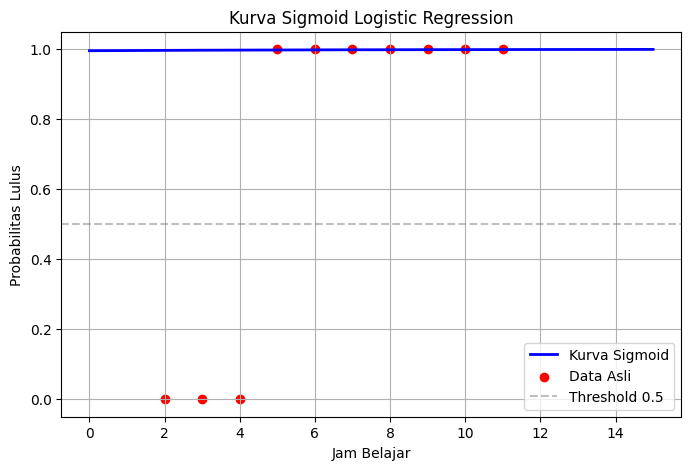

In [173]:
mean_kehadiran = df['kehadiran'].mean()
mean_motivasi  = df['motivasi'].mean()
jam_range = np.linspace(0, 15, 300)

X_plot = np.column_stack([
    jam_range,
    np.full_like(jam_range, mean_kehadiran),
    np.full_like(jam_range, mean_motivasi)
])

prob = model.predict_proba(X_plot)[:, 1]

plt.figure(figsize=(8, 5))
plt.plot(jam_range, prob, color='blue', linewidth=2, label='Kurva Sigmoid')
plt.scatter(df['jam_belajar'], y, color='red', label='Data Asli')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold 0.5')
plt.xlabel("Jam Belajar")
plt.ylabel("Probabilitas Lulus")
plt.title("Kurva Sigmoid Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()


In [174]:
import sklearn.metrics as metrics
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 0.0
MSE: 0.0
RMSE: 0.0


In [175]:
data_baru = [[12, 80, 7]]
prediksi = model.predict(data_baru)
print("Prediksi kelulusan:", "Lulus" if prediksi[0] == 1 else "Tidak Lulus")

Prediksi kelulusan: Lulus
